In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


In [3]:
# Cargamos los archivos que guardamos en el notebook 02
train = pd.read_csv('../data/train_processed.csv')
test  = pd.read_csv('../data/test_processed.csv')
rul   = pd.read_csv('../data/rul_processed.csv')

# Columnas de sensores y settings
sensor_cols  = [f's{i}' for i in range(1, 22) 
                if f's{i}' in train.columns]
setting_cols = ['setting1', 'setting2']
feature_cols = setting_cols + sensor_cols

# Separamos X e y
X_train = train[feature_cols]
y_train = train['RUL_clipped']

X_test  = test.groupby('unit').last().reset_index()[feature_cols]
y_test  = rul['RUL']

print("✅ Datos cargados correctamente")
print(f"📊 X_train: {X_train.shape}")
print(f"📊 X_test:  {X_test.shape}")
print(f"📊 Features: {len(feature_cols)}")

✅ Datos cargados correctamente
📊 X_train: (20631, 20)
📊 X_test:  (100, 20)
📊 Features: 20


In [4]:
# ============================================
# CELDA 3: Modelo base XGBoost
# ============================================

# Definimos el modelo con parámetros iniciales
model = XGBRegressor(
    n_estimators    = 200,   # número de árboles
    learning_rate   = 0.05,  # qué tan rápido aprende
    max_depth       = 6,     # profundidad de cada árbol
    subsample       = 0.8,   # % de datos por árbol
    colsample_bytree= 0.8,   # % de features por árbol
    random_state    = 42,    # para reproducibilidad
    verbosity       = 0
)

# Entrenamos el modelo
print("⏳ Entrenando modelo...")
model.fit(X_train, y_train)
print("✅ Modelo entrenado exitosamente")

# Primera predicción
y_pred = model.predict(X_test)
print(f"\n📊 Primeras 5 predicciones vs valores reales:")
comparison = pd.DataFrame({
    'RUL Real'     : y_test.values[:5],
    'RUL Predicho' : y_pred[:5].round(1)
})
print(comparison.to_string(index=False))

⏳ Entrenando modelo...
✅ Modelo entrenado exitosamente

📊 Primeras 5 predicciones vs valores reales:
 RUL Real  RUL Predicho
      112    119.099998
       98    121.900002
       69     65.199997
       82     98.699997
       91    113.300003


In [5]:
# ============================================
# CELDA 4: Métricas de evaluación
# ============================================

# Calculamos las métricas principales
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("=" * 45)
print("RESULTADOS DEL MODELO")
print("=" * 45)
print(f"📊 RMSE : {rmse:.2f} ciclos")
print(f"📊 MAE  : {mae:.2f} ciclos")
print(f"📊 R²   : {r2:.4f}")
print("=" * 45)
print(f"""
¿Qué significan estas métricas?

RMSE ({rmse:.1f}): En promedio el modelo se equivoca 
       {rmse:.0f} ciclos al predecir la vida restante

MAE  ({mae:.1f}): Error absoluto promedio de 
       {mae:.0f} ciclos

R²   ({r2:.3f}): El modelo explica el {r2*100:.1f}% 
       de la variación en RUL
       (1.0 = perfecto, 0 = inútil)
""")

RESULTADOS DEL MODELO
📊 RMSE : 18.38 ciclos
📊 MAE  : 13.30 ciclos
📊 R²   : 0.8045

¿Qué significan estas métricas?

RMSE (18.4): En promedio el modelo se equivoca 
       18 ciclos al predecir la vida restante

MAE  (13.3): Error absoluto promedio de 
       13 ciclos

R²   (0.804): El modelo explica el 80.4% 
       de la variación en RUL
       (1.0 = perfecto, 0 = inútil)



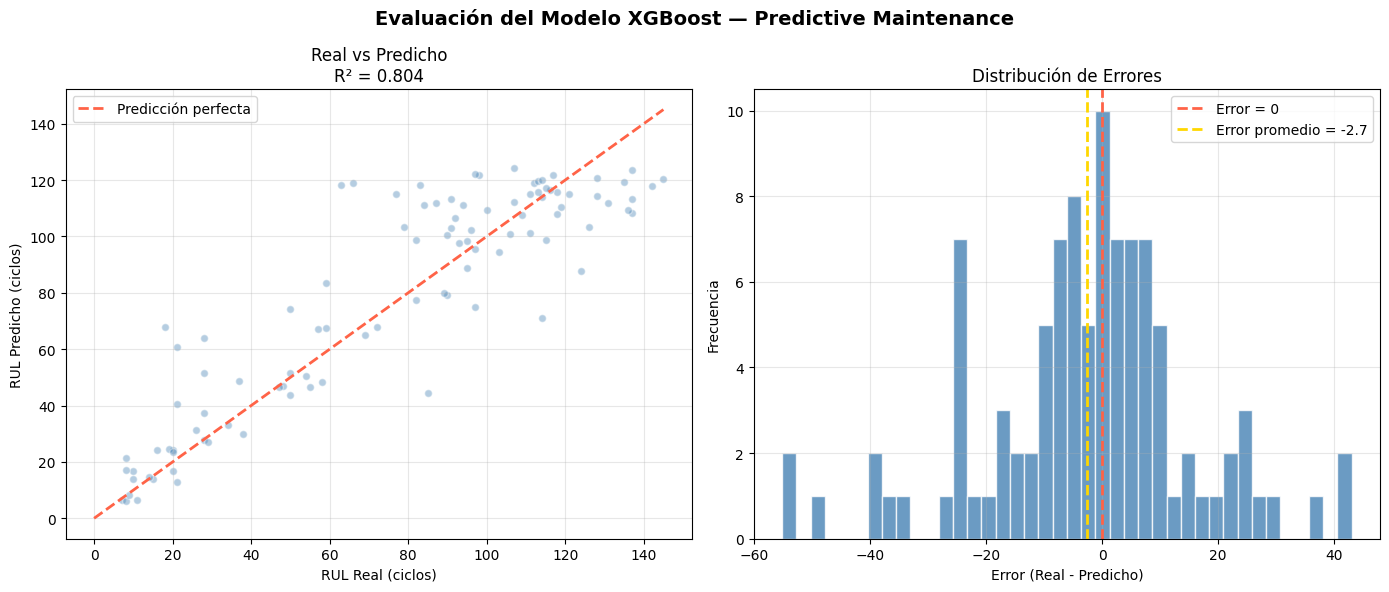

✅ Gráfica guardada en src/


In [6]:
# ============================================
# CELDA 5: Predicciones vs Realidad
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Evaluación del Modelo XGBoost — Predictive Maintenance',
             fontsize=14, fontweight='bold')

# Gráfica 1: Scatter plot predicho vs real
ax1 = axes[0]
ax1.scatter(y_test, y_pred, alpha=0.4, 
            color='steelblue', edgecolors='white', s=30)

# Línea perfecta (si predijera perfecto todos los puntos estarían aquí)
max_val = max(y_test.max(), y_pred.max())
ax1.plot([0, max_val], [0, max_val], 
         color='tomato', linewidth=2, linestyle='--', 
         label='Predicción perfecta')

ax1.set_xlabel('RUL Real (ciclos)')
ax1.set_ylabel('RUL Predicho (ciclos)')
ax1.set_title(f'Real vs Predicho\nR² = {r2:.3f}')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfica 2: Distribución de errores
ax2 = axes[1]
errors = y_test.values - y_pred
ax2.hist(errors, bins=40, color='steelblue', 
         edgecolor='white', alpha=0.8)
ax2.axvline(x=0, color='tomato', linewidth=2, 
            linestyle='--', label='Error = 0')
ax2.axvline(x=errors.mean(), color='gold', linewidth=2,
            linestyle='--', label=f'Error promedio = {errors.mean():.1f}')
ax2.set_xlabel('Error (Real - Predicho)')
ax2.set_ylabel('Frecuencia')
ax2.set_title('Distribución de Errores')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../src/model_evaluation.png', dpi=150)
plt.show()
print("✅ Gráfica guardada en src/")

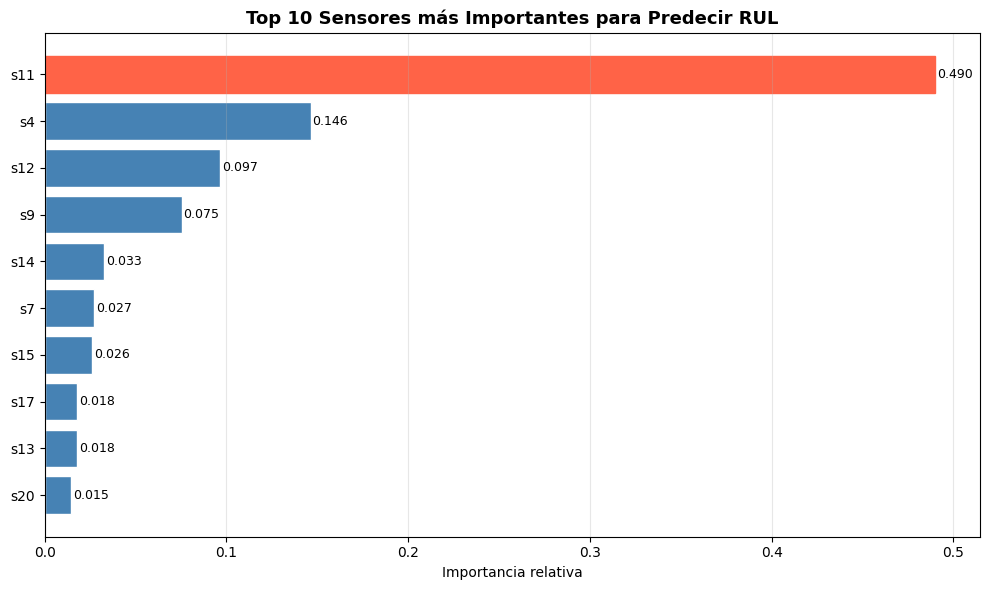

Top 5 sensores más críticos:
feature  importance
    s11    0.489965
     s4    0.146390
    s12    0.096719
     s9    0.075372
    s14    0.032804


In [7]:
# ============================================
# CELDA 6: ¿Qué sensores importan más?
# ============================================

# XGBoost puede decirnos qué features usó más para predecir
importances = pd.DataFrame({
    'feature'   : feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

# Top 10 features más importantes
top10 = importances.head(10)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top10['feature'], top10['importance'],
               color='steelblue', edgecolor='white')

# Colorea la barra más importante
bars[0].set_color('tomato')

ax.set_xlabel('Importancia relativa')
ax.set_title('Top 10 Sensores más Importantes para Predecir RUL',
             fontsize=13, fontweight='bold')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

# Agrega valores en las barras
for bar, val in zip(bars, top10['importance']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../src/feature_importance.png', dpi=150)
plt.show()

print("Top 5 sensores más críticos:")
print(top10[['feature', 'importance']].head().to_string(index=False))

In [8]:
# ============================================
# CELDA 7: Cross Validation
# ============================================

# La validación cruzada confirma que el modelo
# no está memorizando — funciona con datos nuevos

print("⏳ Corriendo validación cruzada (puede tardar 1-2 min)...")

cv_scores = cross_val_score(
    model, X_train, y_train,
    cv      = 5,           # 5 particiones
    scoring = 'neg_mean_squared_error',
    n_jobs  = -1           # usa todos los núcleos de tu PC
)

cv_rmse = np.sqrt(-cv_scores)

print(f"\n✅ Validación cruzada completada")
print(f"📊 RMSE por fold: {cv_rmse.round(2)}")
print(f"📊 RMSE promedio: {cv_rmse.mean():.2f} ± {cv_rmse.std():.2f}")
print(f"""
¿Qué significa esto?
Si el RMSE de CV es similar al RMSE del test,
tu modelo generaliza bien — no está memorizando los datos.

RMSE test : {rmse:.2f}
RMSE CV   : {cv_rmse.mean():.2f}
Diferencia: {abs(rmse - cv_rmse.mean()):.2f} ciclos
""")

⏳ Corriendo validación cruzada (puede tardar 1-2 min)...

✅ Validación cruzada completada
📊 RMSE por fold: [15.54 19.4  18.58 19.34 19.53]
📊 RMSE promedio: 18.48 ± 1.51

¿Qué significa esto?
Si el RMSE de CV es similar al RMSE del test,
tu modelo generaliza bien — no está memorizando los datos.

RMSE test : 18.38
RMSE CV   : 18.48
Diferencia: 0.10 ciclos



In [9]:
# ============================================
# CELDA 8: Guardar el modelo
# ============================================
import pickle
import os

# Creamos carpeta para el modelo
os.makedirs('../src/model', exist_ok=True)

# Guardamos el modelo entrenado
with open('../src/model/xgboost_rul_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("✅ Modelo guardado en src/model/xgboost_rul_model.pkl")
print(f"""
Este archivo contiene tu modelo entrenado.
En el siguiente notebook lo cargarás para hacer predicciones
sin necesidad de entrenar de nuevo.

Tamaño del archivo: 
{os.path.getsize('../src/model/xgboost_rul_model.pkl') / 1024:.1f} KB
""")

✅ Modelo guardado en src/model/xgboost_rul_model.pkl

Este archivo contiene tu modelo entrenado.
En el siguiente notebook lo cargarás para hacer predicciones
sin necesidad de entrenar de nuevo.

Tamaño del archivo: 
884.9 KB



In [10]:
# ============================================
# CELDA 9: Resumen
# ============================================

print("=" * 50)
print("RESUMEN — Model Training Completo")
print("=" * 50)
print(f"""
Modelo : XGBoost Regressor
Features: {len(feature_cols)} sensores/settings

Resultados:
  ✅ RMSE : {rmse:.2f} ciclos
  ✅ MAE  : {mae:.2f} ciclos  
  ✅ R²   : {r2:.4f}
  ✅ CV RMSE: {cv_rmse.mean():.2f} ± {cv_rmse.std():.2f}

Archivos generados:
  ✅ src/model_evaluation.png
  ✅ src/feature_importance.png
  ✅ src/model/xgboost_rul_model.pkl

Siguiente paso → 04_evaluation.ipynb
""")

RESUMEN — Model Training Completo

Modelo : XGBoost Regressor
Features: 20 sensores/settings

Resultados:
  ✅ RMSE : 18.38 ciclos
  ✅ MAE  : 13.30 ciclos  
  ✅ R²   : 0.8045
  ✅ CV RMSE: 18.48 ± 1.51

Archivos generados:
  ✅ src/model_evaluation.png
  ✅ src/feature_importance.png
  ✅ src/model/xgboost_rul_model.pkl

Siguiente paso → 04_evaluation.ipynb

